In [1]:
# autoreload
%load_ext autoreload
%autoreload 2

from scipy import signal
from scipy import interpolate
from scipy import ndimage
import numpy as np
import pycatch22 
from sktime.transformations.panel import catch22
import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
load_dotenv = dotenv.load_dotenv('../.env')
# load local library
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import extractor
import preprocessing

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

from time import sleep

from scipy.stats import skew, kurtosis
from scipy.fft import rfft, rfftfreq
from scipy.signal import cwt, ricker
import pymannkendall as mk

# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AffinityPropagation, SpectralClustering, HDBSCAN
from sklearn.mixture import GaussianMixture as GMM
from umap import UMAP
from scaler import GaussRankScaler
from sklearn.pipeline import Pipeline

import nolds

import datetime

from numba import jit


d:\VENVS\Envs\base_310\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
d:\VENVS\Envs\base_310\lib\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
d:\VENVS\Envs\base_310\lib\site-packages\umap\distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation

In [2]:
START_TIME = datetime.datetime.now()

In [3]:
AKI_PATH = os.environ['AKI_PATH']
os.chdir(AKI_PATH)

In [4]:
ts_data = pd.read_parquet("ts.parquet.snappy")

In [5]:
ts_data = ts_data.assign(ID=ts_data.ID.astype('int64'))

## Exploration

In [6]:
min_days_length = 1*365
maxts = ts_data.groupby('ID').Time_days.max()
ltids = maxts[maxts>min_days_length].index

print(f'There are {ltids.shape[0]} patients (or {round(100*ltids.shape[0]/maxts.shape[0], 2)}%) with minimally {min_days_length} days of measurements')

There are 7401 patients (or 36.22%) with minimally 365 days of measurements


## Preprocess

In [7]:
RangeList = [1825, 3650] #+ list(np.arange(1*365,10*365, 365))
WINDOW_SIZE = 5 # for smoothing
MIN_MEASUREMENTS_PER_YEAR = 2
SMOOTHING_TYPE = 'gaussian_kernel' # rolling_mean or gaussian_kernel
STANDARDIZE_TS = True
STANDARDIZE_TYPE = 'minmax'
TIME_RESOLUTION = 30 # days, for interpolation.

RangeDFDictRaw = {}
RangeDFDict = {}
RangeDFDict_smoothed = {}
for MinDays in RangeList:
    MIN_MEASUREMENTS = np.floor(MIN_MEASUREMENTS_PER_YEAR*MinDays/365)
    
    print(f'Filtering for min days: {MinDays}')
    ts_temp = preprocessing.get_filtered_df(ts_data.copy(), 
                                            id_col='ID', 
                                            time_col='Time_days',
                                            min_days=MinDays, 
                                            min_measurements=MIN_MEASUREMENTS)
    
    RangeDFDictRaw[MinDays] = ts_temp
     
    if STANDARDIZE_TS:
        print(f'Standardizing for min days: {MinDays}')
        ts_temp = preprocessing.normalise_ts(ts_temp, 
                                             id_col='ID', 
                                             time_col='Time_days',
                                             val_col='eGFR_CKDEpi2012',
                                             df_out=True,
                                             scaler=STANDARDIZE_TYPE)
    
    
    print(f'Interpolating for min days: {MinDays}')
    RangeDFDict[MinDays] = preprocessing.get_interpolated(ts_temp, id_col='ID', time_col='Time_days',
                                              max_days=MinDays,
                                              val_col='eGFR_CKDEpi2012',
                                              time_res=TIME_RESOLUTION,
                                              df_out=True)
    
    print(f"Smoothing for min days: {MinDays} with window {WINDOW_SIZE}")
    if SMOOTHING_TYPE == 'rolling_mean':
        RangeDFDict_smoothed[MinDays] = preprocessing.get_smoothed_rolling_mean(RangeDFDict[MinDays],
                                                        id_col='ID', time_col='Time_days',
                                                        val_col='eGFR_CKDEpi2012', 
                                                        window=WINDOW_SIZE, 
                                                        df_out=True)
    elif SMOOTHING_TYPE == 'gaussian_kernel':
        RangeDFDict_smoothed[MinDays] = preprocessing.get_smoothed_gaussian_kernel(RangeDFDict[MinDays],
                                                        id_col='ID', time_col='Time_days',
                                                        val_col='eGFR_CKDEpi2012', 
                                                        window=WINDOW_SIZE,
                                                        df_out=True)
    

Filtering for min days: 1825
Standardizing for min days: 1825


100%|██████████| 3043/3043 [00:05<00:00, 522.71it/s]


Interpolating for min days: 1825


100%|██████████| 3043/3043 [00:04<00:00, 712.14it/s]


Smoothing for min days: 1825 with window 5


...

100%|██████████| 1366/1366 [00:02<00:00, 573.03it/s]


Interpolating for min days: 3650


100%|██████████| 1366/1366 [00:01<00:00, 791.87it/s]


Smoothing for min days: 3650 with window 5


100%|██████████| 1366/1366 [00:02<00:00, 668.77it/s]


In [8]:
CrossSectDict = {}
# get_smoothNsmooth_diffStatistics
for MinDays in RangeList:
    print(f'Getting cross-sectional features for min days, for the smoothed set, with periods of: {MinDays} days')
    tsS = RangeDFDict_smoothed[MinDays]
    smoothed_cross = extractor.get_crossectional(tsS, 
                                        id_col='ID',
                                        val_col='eGFR_CKDEpi2012',
                                        time_col='Time_days',
                                        tsfresh_features=False,
                                        catch22_features=True,
                                        cesium_features=False,
                                        antropy_features=False,
                                        nolds_features=False)
    ############
    print(f'Getting cross-sectional features for min days, for the raw set, with periods of: {MinDays} days')
    tsR = RangeDFDict[MinDays]
    raw_cross = extractor.get_crossectional(tsR, 
                                        id_col='ID',
                                        val_col='eGFR_CKDEpi2012',
                                        time_col='Time_days',
                                        tsfresh_features=False,
                                        catch22_features=True,
                                        cesium_features=False,
                                        antropy_features=False,
                                        nolds_features=False)
    ############
    print(f'Merging cross-sectional features for min days, the raw set, with periods of: {MinDays} days')
    merged_cross = smoothed_cross.merge(raw_cross,
                                        left_index=True, 
                                        right_index=True, 
                                        suffixes=('_smoothed', '_raw'))
    smoothNsmoothStats = extractor.get_smoothNsmooth_diffStatistics(tsS,tsR, 
                                                                    id_col='ID',
                                                                    val_col='eGFR_CKDEpi2012',
                                                                    time_col='Time_days')
    
    smoothed_cross = smoothed_cross.merge(smoothNsmoothStats, left_index=True, right_index=True)
    raw_cross = raw_cross.merge(smoothNsmoothStats, left_index=True, right_index=True)
    merged_cross = merged_cross.merge(smoothNsmoothStats, left_index=True, right_index=True)

    CrossSectDict[MinDays] = {
                              'smoothed': smoothed_cross,
                              'raw': raw_cross,
                              'merged': merged_cross
                            }
    
    gc.collect()

Getting cross-sectional features for min days, for the smoothed set, with periods of: 1825 days


  1%|          | 25/3043 [00:04<03:45, 13.39it/s] t:\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: divide by zero encountered in log2
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
t:\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: invalid value encountered in multiply
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
100%|██████████| 3043/3043 [00:06<00:00, 472.11it/s]


Getting cross-sectional features for min days, for the raw set, with periods of: 1825 days


 21%|██▏       | 648/3043 [00:45<02:40, 14.95it/s]t:\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: divide by zero encountered in log2
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
t:\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: invalid value encountered in multiply
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
100%|██████████| 3043/3043 [00:06<00:00, 487.85it/s]


Merging cross-sectional features for min days, the raw set, with periods of: 1825 days
Getting cross-sectional features for min days, for the smoothed set, with periods of: 3650 days


 16%|█▌        | 215/1366 [00:33<02:56,  6.53it/s]t:\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: divide by zero encountered in log2
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
t:\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: invalid value encountered in multiply
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
100%|██████████| 1366/1366 [00:04<00:00, 287.74it/s]


Getting cross-sectional features for min days, for the raw set, with periods of: 3650 days


 26%|██▋       | 359/1366 [00:59<02:46,  6.06it/s]t:\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: divide by zero encountered in log2
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
t:\laupodteam\AIOS\Bram\production\TimEx\sandbox\..\src\extractor.py:187: RuntimeWarning: invalid value encountered in multiply
  entropy_per_rel = get_spectral_entropy(ts_data, freq=1)
100%|██████████| 1366/1366 [00:04<00:00, 304.84it/s]


Merging cross-sectional features for min days, the raw set, with periods of: 3650 days


## Remove redundant features

In [9]:
# remove features that have more than N% of missing values
MAX_MISSING_VALUES_PER_COLUMN = 0.5

print("Removing features for all periods that are too sparse")
num_rem = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        missing_ratio = FINAL_FEATURES.isna().sum(axis=0)/\
                            FINAL_FEATURES.shape[0]
        missing_cols = missing_ratio[missing_ratio>MAX_MISSING_VALUES_PER_COLUMN].index
        
        CrossSectDict[period][key] = FINAL_FEATURES.drop(columns=missing_cols)
        num_rem.append(missing_cols.shape[0])
        
print(f"Number of columns removed: {num_rem}")

Removing features for all periods that are too sparse


100%|██████████| 2/2 [00:00<00:00, 111.02it/s]

Number of columns removed: [0, 0, 0, 0, 0, 0]


In [10]:
# remove plus or minus infinity values
print("Removing infinite values")
num_rem = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        inf_cols = FINAL_FEATURES.columns[FINAL_FEATURES.isin([np.inf, -np.inf]).any()]
        CrossSectDict[period][key] = FINAL_FEATURES.drop(columns=inf_cols)
        num_rem.append(inf_cols.shape[0])

Removing infinite values


100%|██████████| 2/2 [00:00<00:00, 18.01it/s]


In [11]:
from sklearn.feature_selection import VarianceThreshold

print("Removing zero variance features for all periods...")
num_zero = []
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        
        var_thresh = VarianceThreshold(threshold=0.)
        var_thresh.fit(FINAL_FEATURES)
        variances = var_thresh.variances_

        # remove features with zero variance
        zero_variance_features = FINAL_FEATURES.columns[variances == 0]
        non_zero_variance_features = FINAL_FEATURES.columns[variances > 0]
        FINAL_FEATURES = FINAL_FEATURES.drop(zero_variance_features, axis=1)
        
        CrossSectDict[period][key] = FINAL_FEATURES
        num_zero.append(zero_variance_features.shape[0])  
        
print(f"Number of columns removed: {num_zero}")

Removing zero variance features for all periods...


100%|██████████| 2/2 [00:00<00:00, 65.51it/s]

Number of columns removed: [1, 0, 1, 1, 0, 1]


In [12]:
# remove features that are highly correlated
print("Removing perfectly correlated features for all periods...")
num_corr = []
duplicated = set()
for period in tqdm(CrossSectDict.keys()):
    for key in CrossSectDict[period].keys():
        FINAL_FEATURES = CrossSectDict[period][key]
        
        #dist_matrix = 1-FINAL_FEATURES.corr(method='spearman').abs()
        #cols = dist_matrix.columns        
        cols = FINAL_FEATURES.columns
        droplist = []
        for i,cl in enumerate(cols):
            for cr in cols[i+1:]:
                if FINAL_FEATURES[cl].equals(FINAL_FEATURES[cr]):
                    droplist.append(cr)
                    duplicated.add((cl, cr))
        to_drop = list(set(droplist))
                
        FINAL_FEATURES = FINAL_FEATURES.drop(columns=to_drop)
        CrossSectDict[period][key] = FINAL_FEATURES
        num_corr.append(len(to_drop))
print(f"Number of columns removed: {num_corr}")

Removing perfectly correlated features for all periods...


100%|██████████| 2/2 [00:00<00:00,  4.95it/s]

Number of columns removed: [0, 0, 0, 0, 0, 0]


In [13]:
print(f"Duplicate column-pairs: {duplicated}")


Duplicate column-pairs: set()


## Imputation

In [14]:
pipe_kwargs = {}

In [15]:
#imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer
pipe_kwargs['imputer'] = {'default': {'n_neighbors' :7, 'weights': 'distance'}
                          }

## Scale

In [16]:
#scaler = GaussRankScaler()
#scaler = QuantileTransformer(output_distribution='normal')
scaler = StandardScaler
pipe_kwargs['scaler'] = {'default': {}
                         }


## Reducer

In [17]:
reducer = PCA
#reducer = UMAP(n_components=6, n_neighbors=15, min_dist=0., metric='manhattan')
pipe_kwargs['reducer'] = {'default': {'n_components' : 50},
                          'variable': {'n_components': lambda dim: min(dim, 50)}
                          }

## Cluster

In [18]:
#clusterer = HDBSCAN(min_cluster_size=20, min_samples=15, cluster_selection_epsilon=0.5)
#clusterer = KMeans(n_clusters=3)
clusterer = GMM
pipe_kwargs['clusterer'] = {'default': {'n_components': 3},
                            'variable': {'n_components': [3,6,12,24,32]}
                            }

# Run pipeline

In [19]:
ModelDict = {}
ClustDict = defaultdict(lambda: defaultdict(dict))
for period in tqdm(CrossSectDict.keys()):
    ModelDict[period] = {}
    for preptype in CrossSectDict[period].keys():
        df = CrossSectDict[period][preptype].copy()
        # TODO: this is stupid, improve perhaps?
        if pipe_kwargs['reducer'].get('variable'):
            pipe_kwargs['reducer']['default']['n_components'] = pipe_kwargs['reducer']['variable']['n_components'](df.shape[1])

        if pipe_kwargs['clusterer'].get('variable'):
            # assumes variation of number of components
            if isinstance(pipe_kwargs['clusterer']['variable']['n_components'], list):
                for n_comp in pipe_kwargs['clusterer']['variable']['n_components']:
                    pipe_kwargs['clusterer']['default']['n_components'] = n_comp
                    
                    le_pipe_de_prep = Pipeline([
                                ('scaler', scaler(**pipe_kwargs['scaler']['default'])),
                                ('imputer', imputer(**pipe_kwargs['imputer']['default'])),
                                ('reducer', reducer(**pipe_kwargs['reducer']['default']))])
                    
                    le_pipe_clusterer = Pipeline([
                                ('prepper', le_pipe_de_prep),
                                ('clusterer', clusterer(**pipe_kwargs['clusterer']['default']))],
                                verbose=False)   
                    
                    le_pipe_clusterer.fit(df.values)
                    
                    ModelDict[period][preptype] = {}
                    ModelDict[period][preptype][n_comp] = le_pipe_clusterer
                    
                    clust_clf = le_pipe_clusterer.named_steps['clusterer']
                    
                    if ('labels_' in clust_clf.__dir__()) & ('probabilities_' in clust_clf.__dir__()):
                        CrossSectDict[period][preptype][f'cluster_{n_comp}'] = clust_clf.labels_
                        CrossSectDict[period][preptype][f'cluster_proba{n_comp}'] = clust_clf.probabilities_
                    else:
                        prepped_df = le_pipe_clusterer.named_steps['prepper'].transform(df.values)
                        CrossSectDict[period][preptype][f'cluster_{n_comp}'] = le_pipe_clusterer.predict(df.values)
                        CrossSectDict[period][preptype][f'cluster_proba{n_comp}'] = np.max(le_pipe_clusterer.predict_proba(df.values), axis=1)
                        CrossSectDict[period][preptype][f'AIC_{n_comp}'] = clust_clf.aic(prepped_df)
                        CrossSectDict[period][preptype][f'BIC_{n_comp}'] = clust_clf.bic(prepped_df)                   
            else:
                raise ValueError("We expect a list for n_components :)")                
        else:
            le_pipe_de_prep = Pipeline([
                        ('scaler', scaler(**pipe_kwargs['scaler']['default'])),
                        ('imputer', imputer(**pipe_kwargs['imputer']['default'])),
                        ('reducer', reducer(**pipe_kwargs['reducer']['default']))])
            
            le_pipe_clusterer = Pipeline([
                        ('prepper', le_pipe_de_prep),
                        ('clusterer', clusterer(**pipe_kwargs['clusterer']['default']))],
                        verbose=False)  
            le_pipe_clusterer.fit(df.values)
            
            clust_clf = le_pipe_clusterer.named_steps['clusterer']
            if ('labels_' in clust_clf.__dir__()) & ('probabilities_' in clust_clf.__dir__()):
                CrossSectDict[period][preptype]['cluster'] = clust_clf.labels_
                CrossSectDict[period][preptype]['cluster_proba'] = clust_clf.probabilities_
            else:
                prepped_df = le_pipe_clusterer.named_steps['prepper'].transform(df.values)
                CrossSectDict[period][preptype]['cluster'] = le_pipe_clusterer.predict(df.values)
                CrossSectDict[period][preptype]['cluster_proba'] = np.max(le_pipe_clusterer.predict_proba(df.values), axis=1)               
                CrossSectDict[period][preptype]['AIC'] = clust_clf.aic(prepped_df)
                CrossSectDict[period][preptype]['BIC'] = clust_clf.bic(prepped_df)   
            ModelDict[period][preptype] = le_pipe_clusterer
            
        AIC_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if 'AIC' in c]      
        BIC_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if 'BIC' in c]       
        if len(AIC_cols)>0:     
            ClustDict[period][preptype]['AIC'] = {aic_col.split("_")[1]: CrossSectDict[period][preptype][aic_col].mean() for aic_col in AIC_cols}
            ClustDict[period][preptype]['BIC'] = {bic_col.split("_")[1]: CrossSectDict[period][preptype][bic_col].mean() for bic_col in BIC_cols}
            
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if ('cluster_' in c) & ('_proba' not in c)]      
        cluster_proba_cols = [c for c in CrossSectDict[period][preptype].columns 
                                    if 'cluster_proba' in c]
        
        if len(cluster_cols)>0:
            ClustDict[period][preptype]['clusters']= CrossSectDict[period][preptype][cluster_cols]
        if len(cluster_proba_cols)>0:
            ClustDict[period][preptype]['cluster_probas']= CrossSectDict[period][preptype][cluster_proba_cols]

100%|██████████| 2/2 [00:42<00:00, 21.08s/it]


In [20]:
END_TIME = datetime.datetime.now()
DURATION = (END_TIME-START_TIME)

print(f"The runs took about {END_TIME-START_TIME} h/s")

The runs took about 0:16:48.361328 h/s


## Plot

In [21]:
aic_list = []
bic_list = []
for period in tqdm(ClustDict.keys()):
    for preptype in ClustDict[period].keys():
        tDict = ClustDict[period][preptype]['AIC'].copy()
        tDict['period'] = period
        tDict['preptype'] = preptype        
        aic_list.append(tDict)
        
        tDict = ClustDict[period][preptype]['BIC'].copy()
        tDict['period'] = period
        tDict['preptype'] = preptype        
        bic_list.append(tDict)
        
aic_df = pd.DataFrame(aic_list).set_index(['period', 'preptype']).T
aic_df.columns = ['_'.join([str(_c) for _c in col]).strip() for col in aic_df.columns.values]

bic_df = pd.DataFrame(bic_list).set_index(['period', 'preptype']).T
bic_df.columns = ['_'.join([str(_c) for _c in col]).strip() for col in bic_df.columns.values]

min_aic_ind = [{c: aic_df.index[aic_df[c].argmin()]} for c in aic_df.columns]
min_bic_ind = [{c: bic_df.index[bic_df[c].argmin()]} for c in bic_df.columns]

100%|██████████| 2/2 [00:00<?, ?it/s]


In [22]:
aic_df

,1825_smoothed,1825_raw,1825_merged,3650_smoothed,3650_raw,3650_merged
3,194377.553276,224392.397980,360648.760470,98059.854514,105843.208626,167651.465236
6,168691.952470,198698.534061,336733.558283,87823.758696,92355.658363,158870.731033
12,141247.098350,175080.241164,316444.711644,76553.791258,77345.480942,165404.526535
24,116187.644334,143667.558424,351145.276283,40173.488049,53685.551185,207715.647295
32,89128.644688,137143.929402,334408.210847,2125.037614,26372.164752,240099.457314


In [23]:
bic_df

,1825_smoothed,1825_raw,1825_merged,3650_smoothed,3650_raw,3650_merged
3,218321.476095,248336.320799,384592.683289,118818.370907,126601.725019,188409.981629
6,216585.818708,246592.400298,384627.424520,129346.011125,133877.910792,200392.983462
12,237040.851424,270873.994238,412238.464718,159603.515759,160395.205442,248454.251036
24,307781.171082,335261.085171,542738.803030,206278.156692,219790.219828,373820.315938
32,344588.687217,392603.971932,589868.253376,223599.669019,247846.796156,461574.088719


In [24]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        RangeDFDictRaw[period] = \
            pd.merge(RangeDFDictRaw[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

100%|██████████| 2/2 [00:00<00:00,  4.94it/s]


In [25]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        RangeDFDict_smoothed[period] = \
            pd.merge(RangeDFDict_smoothed[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

100%|██████████| 2/2 [00:00<00:00,  2.86it/s]


In [26]:
for period in tqdm(CrossSectDict.keys()):
    for preptype in CrossSectDict[period].keys():
        cluster_cols = [c for c in CrossSectDict[period][preptype].columns 
                            if any([_c in c for _c in ['cluster_', 'AIC_', 'BIC_']])]
        #RangeDFDict[period] = pd.DataFrame(RangeDFDict[period])
        RangeDFDict[period] = \
            pd.merge(RangeDFDict[period],
                    CrossSectDict[period][preptype][cluster_cols], 
                    left_on='ID', 
                    right_index=True, 
                    how='left',
                    suffixes = ('', f'_{preptype}')
                )

100%|██████████| 2/2 [00:00<00:00,  3.03it/s]


In [27]:
RangeDFDict_smoothed[3650].cluster_24_merged.value_counts()

cluster_24_merged
16    35496
3     34452
20    30276
8     27144
6     25056
1     24012
19    22707
5     22446
17    21141
22    20097
12    19053
23    14616
2     13572
0     11484
10    10440
11     5481
21     4698
9      3132
13     2871
14     2871
7      2349
4      2088
18      783
15      261
Name: count, dtype: int64

<Axes: xlabel='Time_days', ylabel='eGFR_CKDEpi2012'>

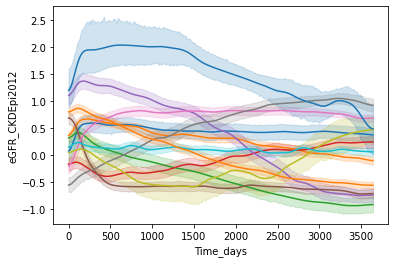

In [28]:
#sns.color_palette("tab10")
sns.lineplot(data=RangeDFDict_smoothed[3650], 
             x='Time_days',
             y='eGFR_CKDEpi2012',
             hue='cluster_12_merged',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             legend=False,
             )

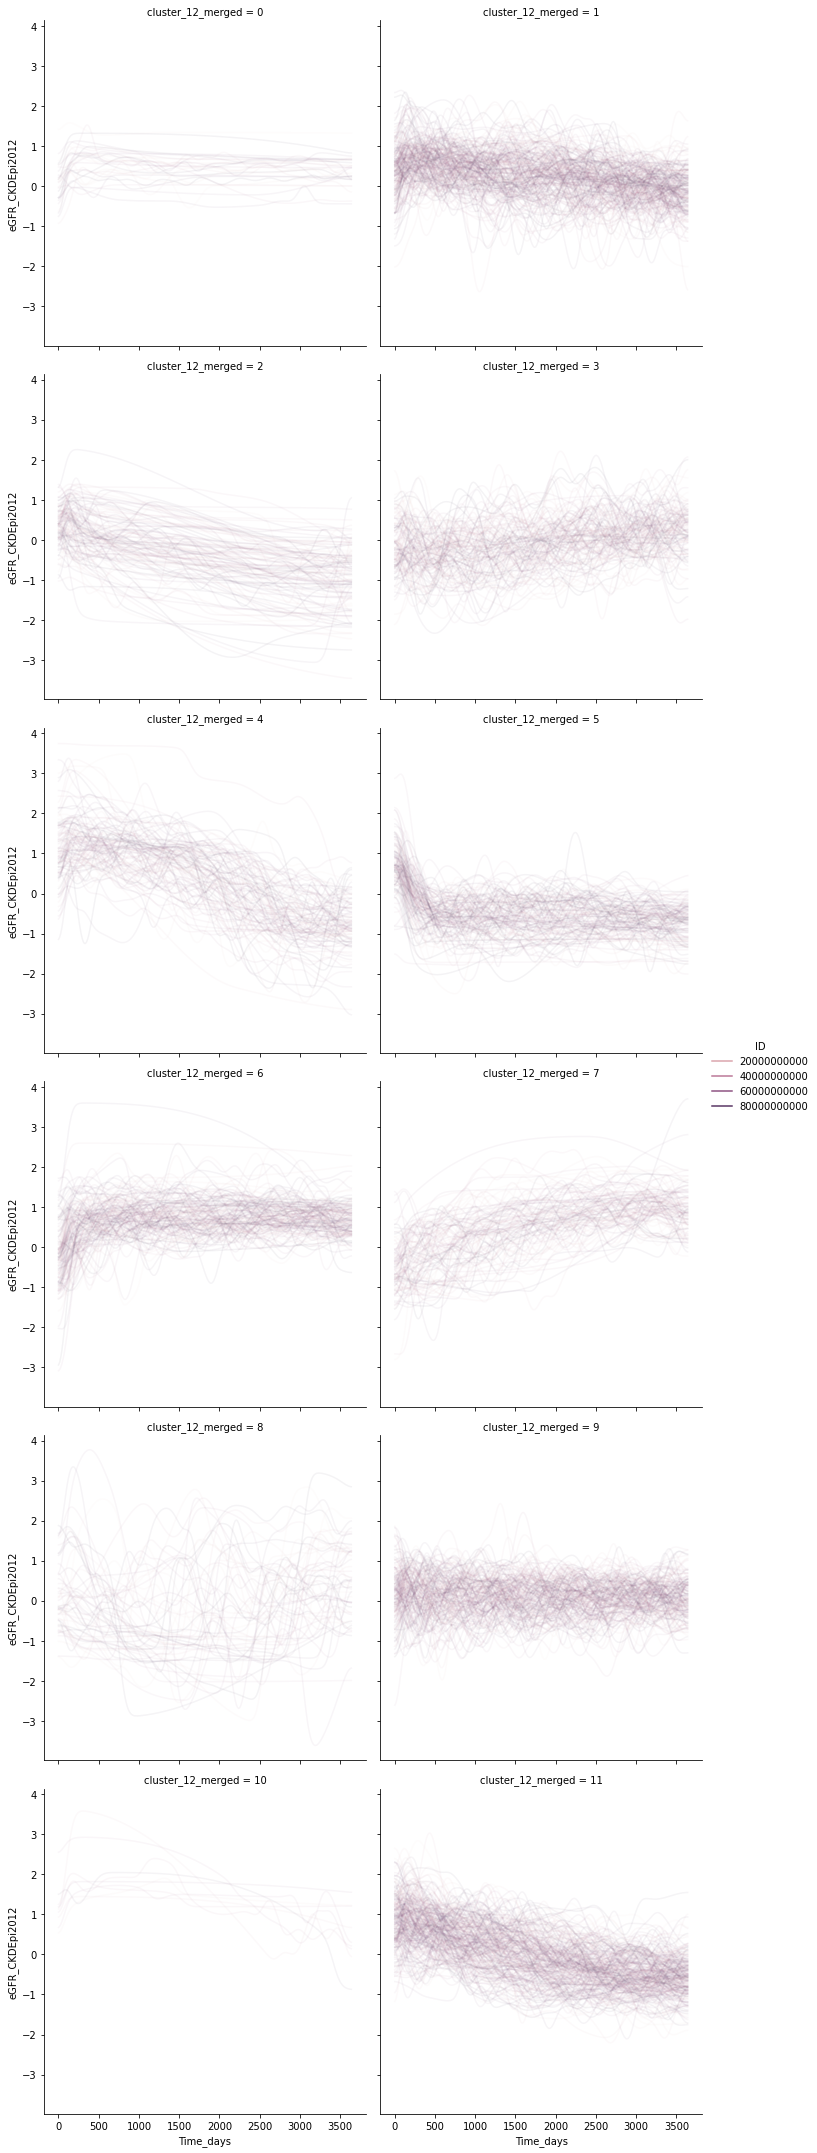

In [29]:
sns.relplot(data=RangeDFDict_smoothed[3650], 
             x='Time_days',
             y='eGFR_CKDEpi2012',
             hue='ID',
             kind='line',
             col='cluster_12_merged',
             col_wrap=2,
             alpha=0.05,
             color='black'
             )